In [2]:
import sionna
import tensorflow as tf

print(f"Sionna Version: {sionna.__version__}")

# 경로 찾기 시도
try:
    # 경우 1: 사용자의 폴더 구조에 따른 경로 (유력)
    from sionna.phy.channel.tr38901 import TDL
    print("✅ TDL 찾음: sionna.phy.channel.tr38901.TDL")
except ImportError:
    try:
        # 경우 2: 다른 경로 시도
        from sionna.channel.tr38901 import TDL
        print("✅ TDL 찾음: sionna.channel.tr38901.TDL")
    except ImportError:
        print("❌ TDL을 찾을 수 없습니다.")

try:
    # CirToCfr 찾기 (보통 utils나 ofdm_channel에 있을 수 있음)
    from sionna.phy.channel import CirToCfr
    print("✅ CirToCfr 찾음: sionna.phy.channel.CirToCfr")
except ImportError:
    print("⚠️ CirToCfr를 찾지 못했습니다. (직접 구현하면 되니 괜찮습니다)")

Sionna Version: 1.2.1
✅ TDL 찾음: sionna.phy.channel.tr38901.TDL
⚠️ CirToCfr를 찾지 못했습니다. (직접 구현하면 되니 괜찮습니다)


✅ TDL 모듈 로드 성공: sionna.phy.channel.tr38901
✅ GPU 2대 감지됨: ['/physical_device:GPU:0', '/physical_device:GPU:1']
>>> [시작] 채널 데이터 생성을 시작합니다...
   - CIR(시간 영역) 계산 중...
   ℹ️ TDL이 (Coefficients, Delays) 튜플을 반환했습니다. 첫 번째 요소만 사용합니다.
   - CIR Squeezed Shape: (23, 42000)
   - Transpose 적용됨 (Time 축 정렬)
   - 정렬된 CIR Shape: (42000, 23)
   - CFR(주파수 영역) 변환 중 (Manual FFT)...
✅ CFR 변환 완료. 최종 데이터 Shape: (42000, 624)

>>> 데이터 시각화 중...


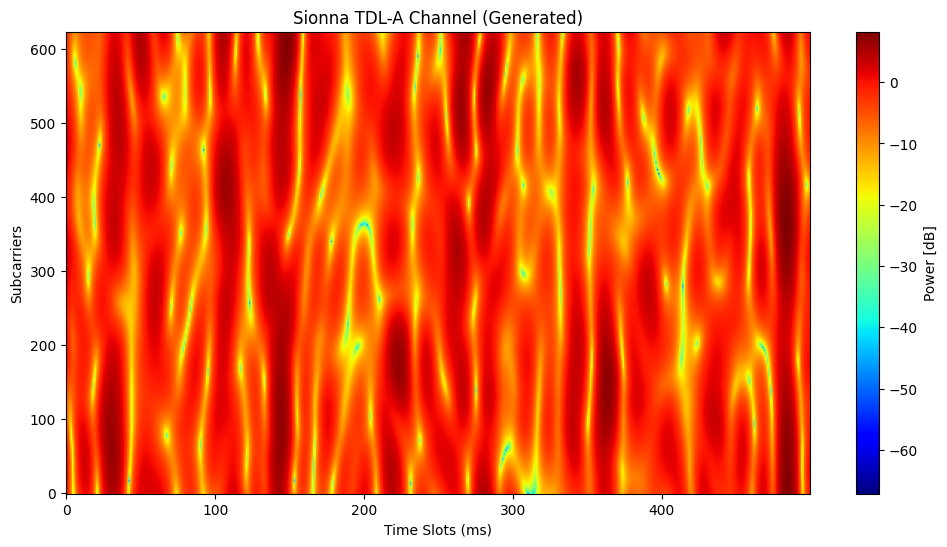

최종 생성된 데이터: (42000, 624)


In [5]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# --- 1. 경로 설정 ---
try:
    from sionna.phy.channel.tr38901 import TDL
    print("✅ TDL 모듈 로드 성공: sionna.phy.channel.tr38901")
except ImportError:
    import sys
    # 혹시 모를 경로 문제 대비
    sys.path.append('/data1/mh/sionna/src')
    from sionna.phy.channel.tr38901 import TDL

# --- 2. GPU 설정 ---
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU {len(gpus)}대 감지됨: {[gpu.name for gpu in gpus]}")
    except RuntimeError as e:
        print(f"⚠️ GPU 설정 오류: {e}")

# 시드 고정
tf.random.set_seed(42)
np.random.seed(42)

# --- 3. 데이터 생성 클래스 (수정됨) ---
class ChannelDataGenerator:
    def __init__(self):
        self.carrier_frequency = 2.0e9
        self.subcarrier_spacing = 15e3
        self.speed = 5.5556
        self.delay_spread = 100e-9
        self.num_time_steps = 42000
        self.num_subcarriers = 624
        self.sampling_frequency = 1000
        
    def generate(self):
        print(">>> [시작] 채널 데이터 생성을 시작합니다...")
        
        # SISO 설정
        tdl = TDL(model="A",
                  delay_spread=self.delay_spread,
                  carrier_frequency=self.carrier_frequency,
                  min_speed=self.speed,
                  max_speed=self.speed,
                  num_rx_ant=1,
                  num_tx_ant=1)

        print("   - CIR(시간 영역) 계산 중...")
        # tdl 호출 결과 받기
        cir_output = tdl(batch_size=1, 
                         num_time_steps=self.num_time_steps, 
                         sampling_frequency=self.sampling_frequency)
        
        # [수정된 부분] 반환값이 튜플인지 확인하여 처리
        if isinstance(cir_output, tuple) or isinstance(cir_output, list):
            print("   ℹ️ TDL이 (Coefficients, Delays) 튜플을 반환했습니다. 첫 번째 요소만 사용합니다.")
            h_time_raw = cir_output[0] # 첫 번째 요소가 채널 계수(Complex)
            # cir_output[1]은 delays(Float)일 것입니다.
        else:
            h_time_raw = cir_output # 텐서 하나만 반환된 경우

        # 차원 제거
        h_time = tf.squeeze(h_time_raw)
        
        # Shape 확인 및 Transpose (Time축 정렬)
        print(f"   - CIR Squeezed Shape: {h_time.shape}")
        
        # 만약 (Paths, Time) 형태라면 (Time, Paths)로 변경
        # 42000이 self.num_time_steps
        if h_time.shape[0] != self.num_time_steps:
             # 42000이 뒤쪽에 있다면 Transpose
             h_time = tf.transpose(h_time)
             print("   - Transpose 적용됨 (Time 축 정렬)")

        print(f"   - 정렬된 CIR Shape: {h_time.shape}") 

        # 3. CFR(주파수 영역) 변환 (Manual FFT)
        print("   - CFR(주파수 영역) 변환 중 (Manual FFT)...")
        
        delays = tf.squeeze(tdl.delays)
        
        frequencies = tf.cast(tf.range(self.num_subcarriers), tf.float32) * self.subcarrier_spacing
        
        # DFT Matrix
        omega = -1j * 2 * np.pi * tf.cast(frequencies[:, None], tf.complex64) * tf.cast(delays[None, :], tf.complex64)
        dft_mat = tf.exp(omega) 
        
        # 변환
        h_time_complex = tf.cast(h_time, tf.complex64)
        h_freq = tf.matmul(h_time_complex, dft_mat, transpose_b=True)
        
        print(f"✅ CFR 변환 완료. 최종 데이터 Shape: {h_freq.shape}")
        
        return h_freq.numpy()

# --- 4. 실행 및 확인 ---
if __name__ == "__main__":
    generator = ChannelDataGenerator()
    raw_data = generator.generate()

    # --- 5. 시각화 ---
    print("\n>>> 데이터 시각화 중...")
    
    # 500ms 구간 시각화
    power_db = 10 * np.log10(np.abs(raw_data[:500, :])**2 + 1e-12)
    
    plt.figure(figsize=(12, 6))
    plt.imshow(power_db.T, aspect='auto', origin='lower', cmap='jet')
    plt.colorbar(label='Power [dB]')
    plt.title('Sionna TDL-A Channel (Generated)')
    plt.xlabel('Time Slots (ms)')
    plt.ylabel('Subcarriers')
    plt.show()
    
    print(f"최종 생성된 데이터: {raw_data.shape}")

In [6]:
# 현재 폴더에 'raw_channel_data.npy' 라는 이름으로 저장합니다.
np.save('raw_channel_data.npy', raw_data)
print("✅ 데이터가 'raw_channel_data.npy' 파일로 저장되었습니다!")

✅ 데이터가 'raw_channel_data.npy' 파일로 저장되었습니다!


✅ Raw 데이터 로드 성공: (42000, 624) (Complex 유지)

>>> [Wide Model Tuning] Window: 60...

>>> 학습 시작 (Wide Model)...
Epoch 1/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.2561 - val_loss: 0.1055 - learning_rate: 5.0000e-04
Epoch 2/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0664 - val_loss: 0.2099 - learning_rate: 5.0000e-04
Epoch 3/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0639 - val_loss: 0.1728 - learning_rate: 5.0000e-04
Epoch 4/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0629 - val_loss: 0.1131 - learning_rate: 5.0000e-04
Epoch 5/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0622 - val_loss: 0.0763 - learning_rate: 5.0000e-04
Epoch 6/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0616 - val_loss: 0.0798 - learning_rate: 5.0000e-04
Epoch 7/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0611 - val_loss: 0.0693 - learning_rate: 5.0000e-04
Epoch 8/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0606 - val_loss

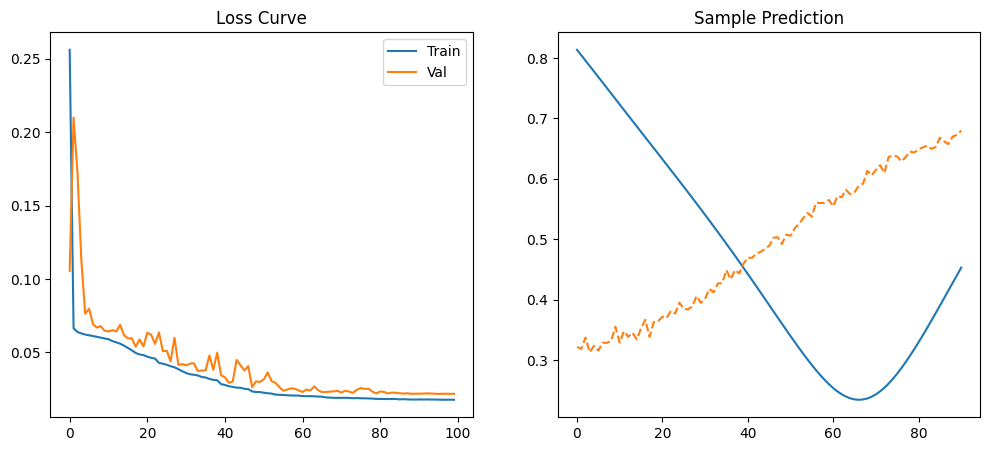

In [4]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# ==========================================
# 1. 설정
# ==========================================
WINDOW_SIZE = 60        
PREDICTION_HORIZON = 14 
SUB_CARRIERS = 91       
CENTER_IDX = 624 // 2
SNR_DB = 30.0           

BATCH_SIZE = 128
EPOCHS = 100

# ==========================================
# 2. 데이터 로드 및 전처리 (수정 없음, 완벽함)
# ==========================================
try:
    raw_data = np.load('raw_channel_data.npy') 
    print(f"✅ Raw 데이터 로드 성공: {raw_data.shape} (Complex 유지)")
except FileNotFoundError:
    raise Exception("데이터 파일이 없습니다.")

def preprocess_wide(data, snr_db):
    print(f"\n>>> [Wide Model Tuning] Window: {WINDOW_SIZE}...")
    
    start = CENTER_IDX - (SUB_CARRIERS // 2)
    end = CENTER_IDX + (SUB_CARRIERS // 2) + 1
    data_cropped = data[:, start:end]
    
    sig_power = np.mean(np.abs(data_cropped)**2)
    noise_power = sig_power / (10**(snr_db/10))
    noise = (np.random.randn(*data_cropped.shape) + 1j * np.random.randn(*data_cropped.shape)) * np.sqrt(noise_power/2)
    
    noisy_input = data_cropped + noise
    clean_target = data_cropped

    num_samples = len(data_cropped) - WINDOW_SIZE - PREDICTION_HORIZON
    X_list, Y_list = [], []
    for i in range(num_samples):
        X_list.append(noisy_input[i : i+WINDOW_SIZE])
        Y_list.append(clean_target[i + WINDOW_SIZE + PREDICTION_HORIZON - 1])
        
    X_complex = np.array(X_list)
    Y_complex = np.array(Y_list)
    
    X_concat = np.concatenate([np.real(X_complex), np.imag(X_complex)], axis=-1)
    Y_concat = np.concatenate([np.real(Y_complex), np.imag(Y_complex)], axis=-1)
    
    split_idx = int(len(X_concat) * 0.8)
    X_train, X_test = X_concat[:split_idx], X_concat[split_idx:]
    Y_train, Y_test = Y_concat[:split_idx], Y_concat[split_idx:]
    
    scaler_x = MinMaxScaler((-1, 1))
    scaler_y = MinMaxScaler((-1, 1))
    
    N_tr, T, F = X_train.shape
    N_te = X_test.shape[0]
    
    X_train_scaled = scaler_x.fit_transform(X_train.reshape(N_tr, -1)).reshape(N_tr, T, F)
    X_test_scaled = scaler_x.transform(X_test.reshape(N_te, -1)).reshape(N_te, T, F)
    Y_train_scaled = scaler_y.fit_transform(Y_train)
    Y_test_scaled = scaler_y.transform(Y_test)
    
    return (X_train_scaled, X_test_scaled, Y_train_scaled, Y_test_scaled), scaler_y

(X_train, X_test, Y_train, Y_test), scaler_y = preprocess_wide(raw_data, SNR_DB)

# ==========================================
# 3. 모델 정의 (Wide & Simple)
# ==========================================
def create_wide_model(input_shape):
    inputs = layers.Input(shape=input_shape)
    
    # [수정] LSTM 층을 1개로 줄이고, 유닛을 512개로 늘림 (Wide Architecture)
    # 파라미터 수: 약 150만개 (충분히 큼) -> 정보 손실 최소화
    # Return Sequences=False로 바로 압축
    x = layers.LSTM(512, return_sequences=False,
                    kernel_regularizer=regularizers.l2(0.00001))(inputs) # L2 규제 아주 약하게
    
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x) # Dropout을 50%로 강력하게 적용 (노드가 많으므로)
    
    outputs = layers.Dense(182, activation='linear')(x)
    
    model = models.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(0.0005), loss='mse')
    return model

# ==========================================
# 4. 학습
# ==========================================
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

print("\n>>> 학습 시작 (Wide Model)...")
model = create_wide_model((WINDOW_SIZE, SUB_CARRIERS * 2))

hist = model.fit(X_train, Y_train, 
                 epochs=EPOCHS, 
                 batch_size=BATCH_SIZE,
                 validation_split=0.2, 
                 callbacks=[reduce_lr, early_stop], 
                 verbose=1)

# ==========================================
# 5. 평가
# ==========================================
print("\n>>> 최종 평가 중...")
pred_concat_scaled = model.predict(X_test)
pred_concat = scaler_y.inverse_transform(pred_concat_scaled)
target_concat = scaler_y.inverse_transform(Y_test)

pred_r = pred_concat[:, :SUB_CARRIERS]
pred_i = pred_concat[:, SUB_CARRIERS:]
target_r = target_concat[:, :SUB_CARRIERS]
target_i = target_concat[:, SUB_CARRIERS:]

H_pred = pred_r + 1j * pred_i
H_true = target_r + 1j * target_i

nmse_db = 10 * np.log10(np.sum(np.abs(H_true - H_pred)**2) / np.sum(np.abs(H_true)**2))

print(f"\n========================================")
print(f"🔥 FINAL ATTEMPT (Wide LSTM)")
print(f"NMSE: {nmse_db:.2f} dB")
print(f"========================================")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(hist.history['loss'], label='Train')
plt.plot(hist.history['val_loss'], label='Val')
plt.title('Loss Curve')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(np.abs(H_true[0]), label='True')
plt.plot(np.abs(H_pred[0]), '--', label='Pred')
plt.title('Sample Prediction')
plt.show()

2025-12-23 22:18:28.681024: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766495908.696983 3983302 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766495908.701872 3983302 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766495908.715812 3983302 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766495908.715826 3983302 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766495908.715828 3983302 computation_placer.cc:177] computation placer alr

✅ Raw 데이터 로드 성공: (42000, 624)

>>> [Paper Replication] Window: 60, Horizon: 14...

>>> 학습 시작 (Paper Config: 2 Layers, 200 Units, No Dropout, BS=64)...


I0000 00:00:1766495913.835709 3983302 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22323 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:81:00.0, compute capability: 8.6
I0000 00:00:1766495913.836983 3983302 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 22323 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:c1:00.0, compute capability: 8.6


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 60, 182)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 60, 200)        │       306,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 200)            │       320,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 182)            │        36,582 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

 Trainable params: 663,782 (2.53 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/400


I0000 00:00:1766495917.948253 3983596 cuda_dnn.cc:529] Loaded cuDNN version 90300


420/420 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.0535 - val_loss: 0.0466 - learning_rate: 5.0000e-04
Epoch 2/400
420/420 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0351 - val_loss: 0.0288 - learning_rate: 5.0000e-04
Epoch 3/400
420/420 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0228 - val_loss: 0.0259 - learning_rate: 5.0000e-04
Epoch 4/400
420/420 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0179 - val_loss: 0.0206 - learning_rate: 5.0000e-04
Epoch 5/400
420/420 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0159 - val_loss: 0.0172 - learning_rate: 5.0000e-04
Epoch 6/400
420/420 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0148 - val_loss: 0.0183 - learning_rate: 5.0000e-04
Epoch 7/400
420/420 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0140 - val_loss: 0.0180 - learning_rate: 5.0000e-04
Epoch 8/400
420/420 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0133 - val_loss: 0.0164 - learning_rate: 5.0000e-04
Epoch 9/400
420/420 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0133 - val_loss: 0.0

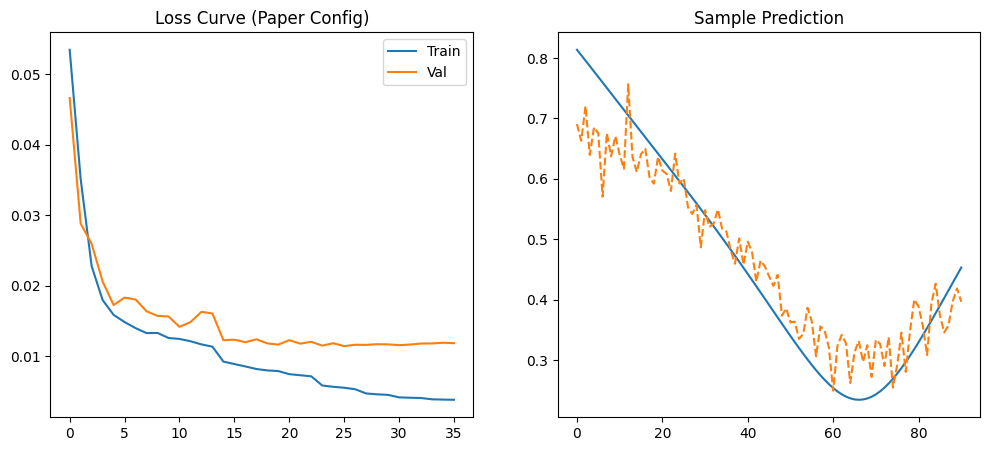

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# ==========================================
# 0. GPU 설정
# ==========================================
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# ==========================================
# 1. 설정 (논문 Table 4 & Section 5.4.2 준수)
# ==========================================
WINDOW_SIZE = 60        # [cite: 1689] Past 60 timeslots
PREDICTION_HORIZON = 14 
SUB_CARRIERS = 91       
CENTER_IDX = 624 // 2
SNR_DB = 30.0           

# [논문 설정]
BATCH_SIZE = 64         #  Table 4
EPOCHS = 400             #  Table 4 (논문은 40 epoch만 학습)
LEARNING_RATE = 0.0005  # [cite: 2574] Table 4

# ==========================================
# 2. 데이터 로드 및 전처리 (성능 검증된 방식 유지)
# ==========================================
try:
    raw_data = np.load('raw_channel_data.npy')
    print(f"✅ Raw 데이터 로드 성공: {raw_data.shape}")
except FileNotFoundError:
    raise Exception("데이터 파일이 없습니다.")

def preprocess_paper_exact(data, snr_db):
    print(f"\n>>> [Paper Replication] Window: {WINDOW_SIZE}, Horizon: {PREDICTION_HORIZON}...")
    
    # Crop
    start = CENTER_IDX - (SUB_CARRIERS // 2)
    end = CENTER_IDX + (SUB_CARRIERS // 2) + 1
    data_cropped = data[:, start:end]
    
    # Noise Injection
    sig_power = np.mean(np.abs(data_cropped)**2)
    noise_power = sig_power / (10**(snr_db/10))
    noise = (np.random.randn(*data_cropped.shape) + 1j * np.random.randn(*data_cropped.shape)) * np.sqrt(noise_power/2)
    noisy_input = data_cropped + noise
    clean_target = data_cropped

    # Windowing
    num_samples = len(data_cropped) - WINDOW_SIZE - PREDICTION_HORIZON
    X_list, Y_list = [], []
    for i in range(num_samples):
        X_list.append(noisy_input[i : i+WINDOW_SIZE])
        Y_list.append(clean_target[i + WINDOW_SIZE + PREDICTION_HORIZON - 1])
        
    X_complex = np.array(X_list)
    Y_complex = np.array(Y_list)
    
    # Concatenation (Real + Imag) -> (N, 60, 182)
    X_concat = np.concatenate([np.real(X_complex), np.imag(X_complex)], axis=-1)
    Y_concat = np.concatenate([np.real(Y_complex), np.imag(Y_complex)], axis=-1)
    
    # Split
    split_idx = int(len(X_concat) * 0.8)
    X_train, X_test = X_concat[:split_idx], X_concat[split_idx:]
    Y_train, Y_test = Y_concat[:split_idx], Y_concat[split_idx:]
    
    # MinMax Scaling (-1 ~ 1)
    scaler_x = MinMaxScaler((-1, 1))
    scaler_y = MinMaxScaler((-1, 1))
    
    N_tr, T, F = X_train.shape
    N_te = X_test.shape[0]
    
    X_train_scaled = scaler_x.fit_transform(X_train.reshape(N_tr, -1)).reshape(N_tr, T, F)
    X_test_scaled = scaler_x.transform(X_test.reshape(N_te, -1)).reshape(N_te, T, F)
    Y_train_scaled = scaler_y.fit_transform(Y_train)
    Y_test_scaled = scaler_y.transform(Y_test)
    
    return (X_train_scaled, X_test_scaled, Y_train_scaled, Y_test_scaled), scaler_y

(X_train, X_test, Y_train, Y_test), scaler_y = preprocess_paper_exact(raw_data, SNR_DB)

# ==========================================
# 3. 모델 정의 (Figure 39 & Section 5.4.2)
# ==========================================
def create_figure39_lstm(input_shape):
    inputs = layers.Input(shape=input_shape)
    
    # [cite: 2552-2555] Layer 1: LSTM 200 units
    # "2 hidden layers with 200 neurons in each" 
    x = layers.LSTM(200, return_sequences=True)(inputs)
    
    # 논문 Section 5.3: Dropout을 테스트했으나 0이 가장 좋았음 
    # 따라서 Dropout Layer 제거 (Pure LSTM)
    
    # [cite: 2557-2560] Layer 2: LSTM 200 units
    x = layers.LSTM(200, return_sequences=False)(x)
    
    # [cite: 2563-2565] Output Layer
    outputs = layers.Dense(182, activation='linear')(x)
    
    model = models.Model(inputs=inputs, outputs=outputs)
    
    # [cite: 2574] Optimizer: Adam, LR=0.0005
    opt = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
    model.compile(optimizer=opt, loss='mse')
    return model

# ==========================================
# 4. 학습
# ==========================================
# [cite: 2579] Callbacks: ReduceLROnPlateau, EarlyStopping
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print(f"\n>>> 학습 시작 (Paper Config: 2 Layers, 200 Units, No Dropout, BS={BATCH_SIZE})...")
model = create_figure39_lstm((WINDOW_SIZE, SUB_CARRIERS * 2))
model.summary() # 파라미터 수가 약 558,420개에 가까운지 확인 

hist = model.fit(X_train, Y_train, 
                 epochs=EPOCHS, 
                 batch_size=BATCH_SIZE,
                 validation_split=0.2, 
                 callbacks=[reduce_lr, early_stop], 
                 verbose=1)

# ==========================================
# 5. 평가
# ==========================================
print("\n>>> 최종 평가 중...")
pred_concat_scaled = model.predict(X_test)
pred_concat = scaler_y.inverse_transform(pred_concat_scaled)
target_concat = scaler_y.inverse_transform(Y_test)

# 복소수 재구성
pred_r = pred_concat[:, :SUB_CARRIERS]
pred_i = pred_concat[:, SUB_CARRIERS:]
target_r = target_concat[:, :SUB_CARRIERS]
target_i = target_concat[:, SUB_CARRIERS:]

H_pred = pred_r + 1j * pred_i
H_true = target_r + 1j * target_i

nmse_db = 10 * np.log10(np.sum(np.abs(H_true - H_pred)**2) / np.sum(np.abs(H_true)**2))

print(f"\n========================================")
print(f"🔥 PAPER REPLICATION RESULT (Figure 39)")
print(f"NMSE: {nmse_db:.2f} dB")
print(f"========================================")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(hist.history['loss'], label='Train')
plt.plot(hist.history['val_loss'], label='Val')
plt.title('Loss Curve (Paper Config)')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(np.abs(H_true[0]), label='True')
plt.plot(np.abs(H_pred[0]), '--', label='Pred')
plt.title('Sample Prediction')
plt.show()